In [143]:
import serial
import pandas as pd
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Initialisierung

window_size = 3
features = []

data = []
start_time = time.time()
duration = 30  # Dauer der Datensammlung in Sekunden

print("Datensammlung startet...")

# 3. Datensammlung
while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")
    # 5. Daten in einen DataFrame umwandeln und speichern
    columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]  # Spaltennamen ohne Zustand
    df = pd.DataFrame(data, columns=columns)
    #df.head()
    #print(df)
    time.sleep(5)
    # 3. Berechne die Merkmale in Fenstern
    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
        features.append([mean_x, std_x, max_x, min_x, 
                         mean_y, std_y, max_y, min_y, 
                         mean_z, std_z, max_z, min_z,
                         mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                         mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                         mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
    df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
    df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
    features_df = features_df.reset_index(drop=True)
    
    # Kombiniere die beiden DataFrames
    final_df = pd.concat([df_merged, features_df], axis=1)
    final_df = final_df.dropna()
    print(final_df)
    
    final_df_live = final_df[0:30]
    

Datensammlung startet...
Empty DataFrame
Columns: [AccX, AccY, AccZ, GyroX, GyroY, GyroZ, mean_x, std_x, max_x, min_x, mean_y, std_y, max_y, min_y, mean_z, std_z, max_z, min_z, mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x, mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y, mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z]
Index: []

[0 rows x 30 columns]
   AccX  AccY   AccZ  GyroX  GyroY  GyroZ  mean_x     std_x  max_x  min_x  \
1  0.61 -0.26  12.75   -0.1   0.05  -0.01   0.615  0.007071   0.62   0.61   

   ...  max_gyro_x  min_gyro_x  mean_gyro_y  std_gyro_y  max_gyro_y  \
1  ...        -0.1        -0.1        0.055    0.007071        0.06   

   min_gyro_y  mean_gyro_z  std_gyro_z  max_gyro_z  min_gyro_z  
1        0.05        -0.01         0.0       -0.01       -0.01  

[1 rows x 30 columns]
   AccX  AccY   AccZ  GyroX  GyroY  GyroZ  mean_x     std_x  max_x  min_x  \
1  0.61 -0.26  12.75   -0.1   0.05  -0.01   0.615  0.007071   0.62   0.61   
2  0.57 -0.36  12.62   -0.1   0.05  -0

In [144]:
final_df_live

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,mean_x,std_x,max_x,min_x,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
1,0.61,-0.26,12.75,-0.10,0.05,-0.01,0.615,0.007071,0.62,0.61,...,-0.1,-0.1,0.055000,0.007071,0.06,0.05,-0.01,0.0,-0.01,-0.01
2,0.57,-0.36,12.62,-0.10,0.05,-0.01,0.600,0.026458,0.62,0.57,...,-0.1,-0.1,0.053333,0.005774,0.06,0.05,-0.01,0.0,-0.01,-0.01
3,0.61,-0.27,12.69,-0.10,0.06,-0.01,0.600,0.026458,0.62,0.57,...,-0.1,-0.1,0.053333,0.005774,0.06,0.05,-0.01,0.0,-0.01,-0.01
5,0.58,-0.30,12.67,-0.09,0.05,-0.01,0.600,0.026458,0.62,0.57,...,-0.1,-0.1,0.053333,0.005774,0.06,0.05,-0.01,0.0,-0.01,-0.01


In [120]:
import serial
import pandas as pd
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Initialisierung

window_size = 3
features = []

data = []
start_time = time.time()
duration = 30  # Dauer der Datensammlung in Sekunden

print("Datensammlung startet...")

# 3. Datensammlung
while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")
    # 5. Daten in einen DataFrame umwandeln und speichern
    columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]  # Spaltennamen ohne Zustand
    df = pd.DataFrame(data, columns=columns)
    #df.head()
    #print(df)
    time.sleep(5)
    # 3. Berechne die Merkmale in Fenstern
    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
        features.append([mean_x, std_x, max_x, min_x, 
                         mean_y, std_y, max_y, min_y, 
                         mean_z, std_z, max_z, min_z,
                         mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                         mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                         mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
    df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
    df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
    features_df = features_df.reset_index(drop=True)
    
    # Kombiniere die beiden DataFrames
    final_df = pd.concat([df_merged, features_df], axis=1)
    final_df = final_df.dropna()
    print(final_df)
    
    # Daten auslesen 
    knn_df =  pd.read_csv('sensor_data_allg.csv')  
    
    """
# 2. Zielspalte und Merkmale extrahieren
    X = knn_df.drop(columns=['Zustand'])  # Merkmale (Features)
    y = knn_df['Zustand']  # Zielvariable (z. B. Ruhe, Betrieb, Transport)

# 3. Daten in Trainings- und Testdatensatz aufteilen
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Daten skalieren
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

# 5. k-NN Klassifikator erstellen und trainieren
    k = 15  # Anzahl der Nachbarn
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

# 6. Evaluierung auf dem Testdatensatz
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

    joblib.dump(knn, 'knn_model.pkl')  # Speichere das k-NN Modell
    joblib.dump(scaler, 'scaler.pkl')  # Speichere den Scaler
    print("Modell und Scaler wurden gespeichert.")
    
    
    # 9. Neue Daten klassifizieren
    def classify_new_data(new_data):

        # Modell und Scaler laden
        knn_loaded = joblib.load('knn_model.pkl')
        scaler_loaded = joblib.load('scaler.pkl')
    
        # Neue Daten skalieren
        new_data_scaled = scaler_loaded.transform(new_data)
    
        # Vorhersage
        prediction = knn_loaded.predict(new_data_scaled)
        return prediction

# Beispiel: Neue Daten klassifizieren
#new_data_example = final_df  # Beispielhafte Eingabedaten
    
    new_prediction = classify_new_data(final_df)
    print(f"Die vorhergesagte Klasse für die neuen Daten ist: {new_prediction[0]}")
    
    """

# 4. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")


Datensammlung startet...
Empty DataFrame
Columns: [AccX, AccY, AccZ, GyroX, GyroY, GyroZ, mean_x, std_x, max_x, min_x, mean_y, std_y, max_y, min_y, mean_z, std_z, max_z, min_z, mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x, mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y, mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z]
Index: []

[0 rows x 30 columns]
Fehler beim Lesen der Daten: ClearCommError failed (PermissionError(13, 'Zugriff verweigert', None, 5))
Empty DataFrame
Columns: [AccX, AccY, AccZ, GyroX, GyroY, GyroZ, mean_x, std_x, max_x, min_x, mean_y, std_y, max_y, min_y, mean_z, std_z, max_z, min_z, mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x, mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y, mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z]
Index: []

[0 rows x 30 columns]
Fehler beim Lesen der Daten: ClearCommError failed (PermissionError(13, 'Zugriff verweigert', None, 5))
Empty DataFrame
Columns: [AccX, AccY, AccZ, GyroX, GyroY, GyroZ, mean_x, std_x, max_x, min_x, mean_y, s

In [121]:
final_df

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,mean_x,std_x,max_x,min_x,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z


In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import joblib
import time

# Funktion zur Berechnung der Merkmale
def calculate_features(df, window_size=3):
    features = []
    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
        
        # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

        # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

        features.append([mean_x, std_x, max_x, min_x,
                         mean_y, std_y, max_y, min_y,
                         mean_z, std_z, max_z, min_z,
                         mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                         mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                         mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])
    
    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

    return features_df

# Funktion zum Klassifizieren neuer Daten
def classify_new_data(new_data):
    """
    Klassifiziert neue Daten mit dem gespeicherten Modell und Scaler.
    :param new_data: numpy array oder DataFrame mit den neuen Datenpunkten
    :return: vorhergesagte Klasse(n)
    """
    # Modell und Scaler laden
    knn_loaded = joblib.load('knn_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')

    # Neue Daten skalieren
    new_data_scaled = scaler_loaded.transform(new_data)

    # Vorhersage
    prediction = knn_loaded.predict(new_data_scaled)
    return prediction

# Funktion zur Live-Datenaufnahme und Klassifikation
def live_data_processing(csv_file_path, window_size=3):
    # Initiales Training mit historischen Daten (einmalig)
    df = pd.read_csv(csv_file_path)
    X = df.drop(columns=['Zustand'])
    y = df['Zustand']
    
    # Merkmale berechnen
    features_df = calculate_features(df, window_size)
    
    # Daten in Trainings- und Testdatensatz aufteilen
    X_train, X_test, y_train, y_test = train_test_split(features_df, y, test_size=0.3, random_state=42, stratify=y)

    # Daten skalieren
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # k-NN Klassifikator erstellen und trainieren
    k = 15  # Anzahl der Nachbarn
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Evaluierung auf dem Testdatensatz
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

    # Modell und Scaler speichern
    joblib.dump(knn, 'knn_model.pkl')
    joblib.dump(scaler, 'scaler.pkl')
    print("Modell und Scaler wurden gespeichert.")

    # Jetzt beginnen wir mit der Live-Datenaufnahme
    while True:
        # Live-Daten aus CSV (in diesem Fall simulieren wir dies mit der letzten Zeile der CSV)
        new_data = pd.read_csv(csv_file_path).tail(window_size)
        print(f"Neue Live-Daten: \n{new_data}")

        # Merkmale für die neuen Daten berechnen
        new_features = calculate_features(new_data, window_size)

        # Neue Daten klassifizieren
        prediction = classify_new_data(new_features)
        print(f"Vorhergesagte Klasse: {prediction[0]}")

        # Warten, bevor die nächsten Daten verarbeitet werden
        time.sleep(5)  # Beispiel: 5 Sekunden warten, bevor neue Daten verarbeitet werden

# Beispielaufruf: Live-Datenverarbeitung mit CSV-Datei
live_data_processing('new_data_example_features.csv')


KeyError: "['Zustand'] not found in axis"

# Datenaufnahme: Zustand "Ruhe"

### Dateiname: sensor_data_ruhe.csv

In [69]:
"""

import serial
import pandas as pd
import time

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Label für den Zustand (z. B. "Ruhe", "Transport", "Betrieb")
# Für dieses Beispiel gehen wir davon aus, dass du während der Aufnahme manuell oder durch ein anderes Kriterium
# den Zustand änderst. Du kannst es später anpassen.

zustand = "Ruhe"  # Setze den Zustand manuell oder bestimme ihn auf Basis der Zeit / Bedingungen
data = []

start_time = time.time()
duration = 600  # Dauer der Datensammlung in Sekunden

print(f"Datensammlung für Zustand '{zustand}' startet...")

while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            # Label hinzufügen
            values.append(zustand)
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 3. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 4. Daten in einen DataFrame umwandeln
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "Zustand"]
df = pd.DataFrame(data, columns=columns)

# 5. Daten speichern
df.to_csv("sensor_data_ruhe.csv", index=False)
print("Daten gespeichert in sensor_data_ruhe.csv")

# Optional: Daten anzeigen

"""

Datensammlung für Zustand 'Ruhe' startet...
Datenaufnahme beendet.
Daten gespeichert in sensor_data_ruhe.csv


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Zustand
0,0.68,-0.18,12.48,-0.10,0.06,-0.01,Ruhe
1,0.68,-0.24,12.43,-0.10,0.06,-0.01,Ruhe
2,0.67,-0.29,12.50,-0.10,0.06,-0.01,Ruhe
3,0.68,-0.25,12.52,-0.10,0.06,-0.01,Ruhe
4,0.68,-0.25,12.52,-0.10,0.06,-0.01,Ruhe
...,...,...,...,...,...,...,...
5993,4.22,-0.21,11.67,-0.10,0.10,-0.02,Ruhe
5994,4.20,-0.28,11.75,-0.09,0.08,-0.01,Ruhe
5995,4.05,-0.21,11.80,-0.06,0.06,0.01,Ruhe
5996,4.17,-0.23,11.38,-0.08,0.07,0.00,Ruhe


In [ ]:
df

 # Berechnung der Features

### sensor_data_ruhe_features.csv

In [37]:
import pandas as pd
import numpy as np

# 1. Lade die Rohdaten (z.B. aus 'sensor_data_ruhe.csv')
df = pd.read_csv('sensor_data_ruhe.csv')

# 2. Definiere die Fenstergröße für die Merkmalsberechnung
window_size = 50
features = []

# 3. Berechne die Merkmale in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
#df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
#df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
#features_df = features_df.reset_index(drop=True)

# Entfernen der ersten Zeilen, in denen die rollenden Berechnungen NaN ergeben
#df_merged = df_merged.dropna()

# Kombiniere die beiden DataFrames
#final_df = pd.concat([df_merged, features_df], axis=1)


#features_df = final_df.dropna()


# 6. Speichern der erweiterten Datei
features_df.to_csv('sensor_data_ruhe_features_only.csv', index=False)

# Optional: Zeige die ersten paar Zeilen des neuen DataFrames
final_df.head()


features_df

,mean_x,std_x,max_x,min_x,mean_y,std_y,max_y,min_y,mean_z,std_z,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
0,0.666800,0.026607,0.74,0.61,-0.270200,0.030672,-0.18,-0.33,12.478000,0.045625,...,-0.10,-0.10,0.059400,0.002399,0.06,0.05,-0.010400,1.979487e-03,-0.01,-0.02
1,0.666600,0.039570,0.80,0.57,-0.268000,0.035456,-0.18,-0.35,12.489000,0.125344,...,-0.10,-0.11,0.059800,0.001414,0.06,0.05,-0.010200,1.414214e-03,-0.01,-0.02
2,0.661200,0.035722,0.76,0.59,-0.266800,0.027880,-0.19,-0.32,12.493800,0.049606,...,-0.10,-0.11,0.059600,0.001979,0.06,0.05,-0.010000,3.504671e-18,-0.01,-0.01
3,0.715400,1.809446,8.77,-7.41,-0.291000,0.718363,1.87,-3.10,12.474800,0.079776,...,-0.02,-0.19,0.058800,0.020468,0.13,-0.06,-0.016400,1.801106e-01,0.45,-0.73
4,0.741400,1.739562,9.75,-3.53,-0.327600,0.695691,2.06,-3.38,12.352400,1.044483,...,2.49,-1.62,0.055800,0.209422,0.74,-0.96,-0.036200,1.755561e-01,0.36,-0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.538800,1.143110,2.91,-0.18,2.246800,0.801831,3.14,1.13,11.981800,0.471557,...,0.00,-0.59,0.093800,0.125518,0.45,-0.10,-0.036600,8.615624e-02,0.04,-0.37
116,0.084600,0.095900,0.39,-0.11,1.232000,0.060710,1.40,1.11,12.379200,0.118698,...,-0.08,-0.13,0.061000,0.016933,0.10,0.02,-0.011000,8.630747e-03,0.01,-0.04
117,0.323800,0.150372,0.51,-0.08,-0.075400,0.567127,1.39,-0.58,12.462800,0.180939,...,-0.03,-0.54,0.047800,0.033153,0.12,-0.09,-0.016200,2.212119e-02,0.06,-0.08
118,0.404800,0.032150,0.47,0.33,-0.267000,0.033761,-0.20,-0.34,12.473000,0.048666,...,-0.10,-0.11,0.059000,0.003030,0.06,0.05,-0.010000,3.504671e-18,-0.01,-0.01


# Datenaufnahme: Zustand "Transport"

### Dateiname: sensor_data_transport.csv

In [71]:
"""

import serial
import pandas as pd
import time

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Label für den Zustand (z. B. "Ruhe", "Transport", "Betrieb")
# Für dieses Beispiel gehen wir davon aus, dass du während der Aufnahme manuell oder durch ein anderes Kriterium
# den Zustand änderst. Du kannst es später anpassen.

zustand = "Transport"  # Setze den Zustand manuell oder bestimme ihn auf Basis der Zeit / Bedingungen
data = []

start_time = time.time()
duration = 1200  # Dauer der Datensammlung in Sekunden

print(f"Datensammlung für Zustand '{zustand}' startet...")

while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            # Label hinzufügen
            values.append(zustand)
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 3. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 4. Daten in einen DataFrame umwandeln
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "Zustand"]
df = pd.DataFrame(data, columns=columns)

# 5. Daten speichern
df.to_csv("sensor_data_transport.csv", index=False)
print("Daten gespeichert in sensor_data_transport.csv")

# Optional: Daten anzeigen
df.head()


"""

Datensammlung für Zustand 'Transport' startet...
Datenaufnahme beendet.
Daten gespeichert in sensor_data_transport.csv


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Zustand
0,1.96,9.53,1.93,-0.10,0.06,-0.01,Transport
1,1.94,9.49,2.01,-0.10,0.06,-0.01,Transport
2,1.92,9.42,2.14,-0.11,0.12,-0.02,Transport
3,1.79,9.54,2.43,-0.06,0.15,-0.05,Transport
4,1.39,9.46,2.04,-0.12,-0.23,-0.07,Transport


# Berechnung der Features

### Dateiname: sensor_data_transport_features.csv

In [33]:
import pandas as pd
import numpy as np

# 1. Lade die Rohdaten (z.B. aus 'sensor_data_ruhe.csv')
df = pd.read_csv('sensor_data_transport.csv')

# 2. Definiere die Fenstergröße für die Merkmalsberechnung
window_size = 50
features = []

# 3. Berechne die Merkmale in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
#df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
#df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
#features_df = features_df.reset_index(drop=True)

# Kombiniere die beiden DataFrames
#final_df = pd.concat([df_merged, features_df], axis=1)
features_df = final_df.dropna()
# 6. Speichern der erweiterten Datei
features_df.to_csv('sensor_data_transport_features_only.csv', index=False)

# Optional: Zeige die ersten paar Zeilen des neuen DataFrames
final_df.head()


# 

final_df.head()
#final_df = final_df.dropna()
features_df

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,mean_x,std_x,max_x,min_x,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
0,-0.40,-0.63,12.51,-0.1,0.06,-0.01,-0.391000,0.038359,-0.33,-0.48,...,-0.09,-0.10,0.056667,0.004795,0.06,0.05,-0.010333,1.825742e-03,-0.01,-0.02
1,-0.39,-0.60,12.50,-0.1,0.05,-0.01,-0.376000,0.032334,-0.30,-0.43,...,-0.10,-0.10,0.056333,0.004901,0.06,0.05,-0.010333,1.825742e-03,-0.01,-0.02
2,-0.33,-0.59,12.42,-0.1,0.06,-0.01,-0.390333,0.023116,-0.34,-0.43,...,-0.09,-0.10,0.058333,0.003790,0.06,0.05,-0.010667,2.537081e-03,-0.01,-0.02
3,-0.36,-0.62,12.37,-0.1,0.06,-0.01,-0.383333,0.026695,-0.34,-0.43,...,-0.10,-0.10,0.056000,0.004983,0.06,0.05,-0.011000,3.051286e-03,-0.01,-0.02
4,-0.37,-0.66,12.46,-0.1,0.06,-0.01,-0.387000,0.029261,-0.34,-0.45,...,-0.09,-0.10,0.058333,0.003790,0.06,0.05,-0.010333,1.825742e-03,-0.01,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,-0.39,-0.65,12.42,-0.1,0.06,-0.01,-0.387000,0.026149,-0.34,-0.44,...,-0.10,-0.10,0.057667,0.004302,0.06,0.05,-0.010000,3.528758e-18,-0.01,-0.01
148,-0.41,-0.59,12.46,-0.1,0.06,-0.01,-0.394667,0.032982,-0.31,-0.45,...,-0.10,-0.10,0.057333,0.004498,0.06,0.05,-0.011000,3.051286e-03,-0.01,-0.02
149,-0.40,-0.62,12.49,-0.1,0.05,-0.01,-0.388667,0.030256,-0.32,-0.45,...,-0.10,-0.11,0.059000,0.003051,0.06,0.05,-0.010000,3.528758e-18,-0.01,-0.01
150,-0.40,-0.62,12.48,-0.1,0.06,-0.01,-0.386667,0.022024,-0.35,-0.42,...,-0.10,-0.10,0.058000,0.004068,0.06,0.05,-0.010333,1.825742e-03,-0.01,-0.02


# Datenaufnahme: Zustand "Betrieb"

### Dateiname: sensor_data_betrieb.csv

In [74]:
"""

import serial
import pandas as pd
import time

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Label für den Zustand (z. B. "Ruhe", "Transport", "Betrieb")
# Für dieses Beispiel gehen wir davon aus, dass du während der Aufnahme manuell oder durch ein anderes Kriterium
# den Zustand änderst. Du kannst es später anpassen.

zustand = "Betrieb"  # Setze den Zustand manuell oder bestimme ihn auf Basis der Zeit / Bedingungen
data = []

start_time = time.time()
duration = 1200  # Dauer der Datensammlung in Sekunden

print(f"Datensammlung für Zustand '{zustand}' startet...")

while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            # Label hinzufügen
            values.append(zustand)
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 3. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 4. Daten in einen DataFrame umwandeln
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "Zustand"]
df = pd.DataFrame(data, columns=columns)

# 5. Daten speichern
df.to_csv("sensor_data_betrieb.csv", index=False)
print("Daten gespeichert in sensor_data_betrieb.csv")

# Optional: Daten anzeigen
df.head
"""

Datensammlung für Zustand 'Betrieb' startet...
Datenaufnahme beendet.
Daten gespeichert in sensor_data_betrieb.csv


<bound method NDFrame.head of        AccX  AccY   AccZ  GyroX  GyroY  GyroZ  Zustand
0      0.52 -0.22  12.61  -0.10   0.06  -0.01  Betrieb
1      0.57 -0.19  12.56  -0.10   0.05  -0.01  Betrieb
2      0.52 -0.20  12.61  -0.10   0.06  -0.01  Betrieb
3      0.56 -0.28  12.52  -0.10   0.06  -0.01  Betrieb
4      0.59 -0.25  12.51  -0.10   0.06  -0.01  Betrieb
...     ...   ...    ...    ...    ...    ...      ...
11993  0.42  0.01  11.91  -0.23   0.06   0.59  Betrieb
11994 -0.45  0.12  11.75   0.10   0.09   0.40  Betrieb
11995 -1.00  0.26  12.04   0.02   0.14   0.40  Betrieb
11996  0.54  0.70  13.58  -0.04   0.06   0.10  Betrieb
11997 -0.51  1.56  14.22  -0.14  -0.18   0.04  Betrieb

[11998 rows x 7 columns]>

# Berechnung der Features

### Dateiname: sensor_data_betrieb_features.csv

In [38]:
import pandas as pd
import numpy as np

# 1. Lade die Rohdaten 
df = pd.read_csv('sensor_data_betrieb.csv')

# 2. Definiere die Fenstergröße für die Merkmalsberechnung
window_size = 50
features = []

# 3. Berechne die Merkmale in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
#df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
#df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
#features_df = features_df.reset_index(drop=True)

# Kombiniere die beiden DataFrames
#final_df = pd.concat([df_merged, features_df], axis=1)
final_df = final_df.dropna()
# 6. Speichern der erweiterten Datei
features_df.to_csv('sensor_data_betrieb_features_only.csv', index=False)

# Optional: Zeige die ersten paar Zeilen des neuen DataFrames
final_df.head()
final_df = final_df.dropna()
features_df

,mean_x,std_x,max_x,min_x,mean_y,std_y,max_y,min_y,mean_z,std_z,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
0,2.143000,2.706657,8.22,-0.79,-2.799000,2.518476,0.01,-7.47,11.089400,1.699579,...,1.14,-1.28,0.007400,0.485079,0.84,-1.54,-0.045800,0.222032,0.43,-0.58
1,1.319200,0.778363,2.72,0.11,-1.310200,0.961878,0.88,-4.32,12.408000,0.505452,...,0.95,-0.48,0.001200,0.284323,0.46,-0.53,-0.014000,0.109805,0.26,-0.22
2,4.264600,1.991445,7.64,0.63,-1.953600,2.699734,4.50,-7.35,10.815000,1.291257,...,1.64,-1.99,-0.004200,0.510394,1.52,-0.67,-0.004000,0.546473,0.74,-1.39
3,1.098000,1.163126,3.05,-1.08,-1.528000,1.697213,4.69,-4.80,12.329000,0.950242,...,0.80,-2.07,-0.042000,0.285028,0.57,-0.65,0.281400,0.519254,1.43,-0.66
4,1.997400,2.385485,6.47,-2.82,-2.073200,2.681687,2.65,-6.87,11.688000,1.909793,...,1.60,-1.95,-0.069600,0.895781,1.81,-2.40,-0.080400,1.464298,2.88,-2.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,0.462800,0.897555,2.02,-1.69,-1.167600,0.853458,0.87,-2.53,12.586800,1.220203,...,0.12,-0.54,0.112000,0.188582,0.51,-0.64,0.858800,0.816447,2.28,-0.84
236,-0.422000,0.869593,1.10,-3.07,-1.736200,1.344625,0.59,-4.44,12.480400,1.543800,...,0.51,-0.52,0.123400,0.282616,0.68,-0.64,-0.127800,0.657302,0.84,-1.49
237,0.212200,0.882860,1.75,-1.79,-2.078000,1.323300,1.76,-4.44,12.288400,1.409787,...,0.33,-0.76,0.181000,0.271543,0.75,-0.39,-0.128000,0.846946,1.88,-1.67
238,0.273800,0.881501,1.66,-1.47,-1.571000,0.907878,0.42,-3.32,12.520600,1.375959,...,0.14,-0.43,0.034600,0.162697,0.33,-0.43,0.895000,0.701204,2.37,-0.34


## Kombi. der drei Datensätze

In [39]:
import pandas as pd

# Schritt 1: Daten einlesen
df_ruhe = pd.read_csv('sensor_data_ruhe_features_only.csv')
df_betrieb = pd.read_csv('sensor_data_betrieb_features_only.csv')
df_transport = pd.read_csv('sensor_data_betrieb_features_only.csv')

# Schritt 2: Daten zusammenführen
df_combined = pd.concat([df_ruhe, df_betrieb, df_transport], ignore_index=True)

# Schritt 3: Entfernen von Zeilen mit fehlenden Werten (falls vorhanden)
#df_combined = df_combined.dropna()

# Schritt 4: Speichern des kombinierten Datensatzes
df_combined.to_csv('sensor_data_allg_plus_only.csv', index=False)

# Schritt 5: Überprüfen
df_combined



,mean_x,std_x,max_x,min_x,mean_y,std_y,max_y,min_y,mean_z,std_z,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
0,0.666800,0.026607,0.74,0.61,-0.270200,0.030672,-0.18,-0.33,12.478000,0.045625,...,-0.10,-0.10,0.059400,0.002399,0.06,0.05,-0.010400,1.979487e-03,-0.01,-0.02
1,0.666600,0.039570,0.80,0.57,-0.268000,0.035456,-0.18,-0.35,12.489000,0.125344,...,-0.10,-0.11,0.059800,0.001414,0.06,0.05,-0.010200,1.414214e-03,-0.01,-0.02
2,0.661200,0.035722,0.76,0.59,-0.266800,0.027880,-0.19,-0.32,12.493800,0.049606,...,-0.10,-0.11,0.059600,0.001979,0.06,0.05,-0.010000,3.504671e-18,-0.01,-0.01
3,0.715400,1.809446,8.77,-7.41,-0.291000,0.718363,1.87,-3.10,12.474800,0.079776,...,-0.02,-0.19,0.058800,0.020468,0.13,-0.06,-0.016400,1.801106e-01,0.45,-0.73
4,0.741400,1.739562,9.75,-3.53,-0.327600,0.695691,2.06,-3.38,12.352400,1.044483,...,2.49,-1.62,0.055800,0.209422,0.74,-0.96,-0.036200,1.755561e-01,0.36,-0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.462800,0.897555,2.02,-1.69,-1.167600,0.853458,0.87,-2.53,12.586800,1.220203,...,0.12,-0.54,0.112000,0.188582,0.51,-0.64,0.858800,8.164474e-01,2.28,-0.84
596,-0.422000,0.869593,1.10,-3.07,-1.736200,1.344625,0.59,-4.44,12.480400,1.543800,...,0.51,-0.52,0.123400,0.282616,0.68,-0.64,-0.127800,6.573021e-01,0.84,-1.49
597,0.212200,0.882860,1.75,-1.79,-2.078000,1.323300,1.76,-4.44,12.288400,1.409787,...,0.33,-0.76,0.181000,0.271543,0.75,-0.39,-0.128000,8.469465e-01,1.88,-1.67
598,0.273800,0.881501,1.66,-1.47,-1.571000,0.907878,0.42,-3.32,12.520600,1.375959,...,0.14,-0.43,0.034600,0.162697,0.33,-0.43,0.895000,7.012038e-01,2.37,-0.34


# Aufnahme neuen Daten

In [5]:
import serial
import pandas as pd
import time

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Initialisierung
data = []
start_time = time.time()
duration = 30  # Dauer der Datensammlung in Sekunden

print("Datensammlung startet...")

# 3. Datensammlung
while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
            
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 4. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 5. Daten in einen DataFrame umwandeln und speichern
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]  # Spaltennamen ohne Zustand
df = pd.DataFrame(data, columns=columns)
df.to_csv("new_data_example.csv", index=False)
print("Daten gespeichert in new_data_example.csv")

# Optional: Daten anzeigen
df.head()


Datensammlung startet...
Datenaufnahme beendet.
Daten gespeichert in new_data_example.csv


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
0,-0.36,-0.57,12.48,-0.1,0.06,-0.01
1,-0.33,-0.62,12.44,-0.1,0.06,-0.01
2,-0.38,-0.61,12.47,-0.1,0.06,-0.01
3,-0.35,-0.57,12.33,-0.1,0.06,-0.01
4,-0.38,-0.61,12.40,-0.1,0.06,-0.01


# Berechnung der Features aus den neuen Daten

In [6]:
import pandas as pd
import numpy as np

# 1. Lade die Rohdaten 
df = pd.read_csv('new_data_example.csv')

# 2. Definiere die Fenstergröße für die Merkmalsberechnung
window_size = 50
features = []

# 3. Berechne die Merkmale in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 4. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 5. Füge die Merkmale zu den ursprünglichen Daten hinzu
df_merged = df.iloc[:len(features_df) * window_size]  # Stelle sicher, dass die Länge passt
df_merged = df_merged.reset_index(drop=True)  # Reset Index für den Merge
features_df = features_df.reset_index(drop=True)

# Kombiniere die beiden DataFrames
final_df = pd.concat([df_merged, features_df], axis=1)
final_df = final_df.dropna()
# 6. Speichern der erweiterten Datei
final_df.to_csv('new_data_example_features.csv', index=False)

# Optional: Zeige die ersten paar Zeilen des neuen DataFrames
final_df.head()
final_df = final_df.dropna()
final_df

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,mean_x,std_x,max_x,min_x,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
0,-0.36,-0.57,12.48,-0.1,0.06,-0.01,-0.3786,0.031168,-0.30,-0.46,...,-0.10,-0.10,0.058400,0.003703,0.06,0.05,-0.010200,1.414214e-03,-0.01,-0.02
1,-0.33,-0.62,12.44,-0.1,0.06,-0.01,-0.3962,0.027693,-0.34,-0.45,...,-0.10,-0.10,0.057200,0.004536,0.06,0.05,-0.010600,2.398979e-03,-0.01,-0.02
2,-0.38,-0.61,12.47,-0.1,0.06,-0.01,-0.3848,0.026283,-0.32,-0.43,...,-0.10,-0.10,0.057600,0.004314,0.06,0.05,-0.010400,1.979487e-03,-0.01,-0.02
3,-0.35,-0.57,12.33,-0.1,0.06,-0.01,-0.3858,0.027634,-0.32,-0.43,...,-0.10,-0.10,0.058400,0.003703,0.06,0.05,-0.010400,1.979487e-03,-0.01,-0.02
4,-0.38,-0.61,12.40,-0.1,0.06,-0.01,-0.3840,0.028356,-0.29,-0.43,...,-0.10,-0.10,0.059200,0.002740,0.06,0.05,-0.010400,1.979487e-03,-0.01,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,-0.34,-0.66,12.45,-0.1,0.06,-0.01,-0.3894,0.032288,-0.31,-0.46,...,-0.10,-0.11,0.058600,0.003505,0.06,0.05,-0.010000,3.504671e-18,-0.01,-0.01
181,-0.40,-0.66,12.54,-0.1,0.06,-0.01,-0.3860,0.037742,-0.28,-0.46,...,-0.10,-0.11,0.057600,0.004314,0.06,0.05,-0.010000,3.504671e-18,-0.01,-0.01
182,-0.42,-0.62,12.41,-0.1,0.06,-0.01,-0.3790,0.034301,-0.32,-0.44,...,-0.09,-0.11,0.057600,0.004314,0.06,0.05,-0.010200,1.414214e-03,-0.01,-0.02
183,-0.38,-0.65,12.46,-0.1,0.05,-0.01,-0.3902,0.023255,-0.34,-0.45,...,-0.10,-0.10,0.057400,0.004431,0.06,0.05,-0.010200,1.414214e-03,-0.01,-0.02


# Klassifizierung der Daten

Accuracy des k-NN Klassifikators: 99.44%


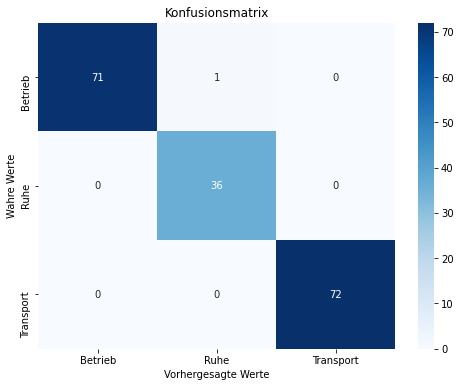

Modell und Scaler wurden gespeichert.


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np
import serial
import pandas as pd
import time
import pandas as pd
import numpy as np




# 1. Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')  # 

# 2. Zielspalte und Merkmale extrahieren
X = df.drop(columns=['Zustand'])  # Merkmale (Features)
y = df['Zustand']  # Zielvariable (z. B. Ruhe, Betrieb, Transport)

# 3. Daten in Trainings- und Testdatensatz aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Daten skalieren
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. k-NN Klassifikator erstellen und trainieren
k = 28  # Anzahl der Nachbarn
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 6. Evaluierung auf dem Testdatensatz
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

# 7. Konfusionsmatrix erstellen und visualisieren
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Wahre Werte")
plt.show()

# 8. Modell und Scaler speichern
joblib.dump(knn, 'knn_model.pkl')  # Speichere das k-NN Modell
joblib.dump(scaler, 'scaler.pkl')  # Speichere den Scaler
print("Modell und Scaler wurden gespeichert.")

# 9. Neue Daten klassifizieren
def classify_new_data(new_data):
    """
    Klassifiziert neue Daten mit dem gespeicherten Modell und Scaler.
    :param new_data: numpy array oder DataFrame mit den neuen Datenpunkten
    :return: vorhergesagte Klasse(n)
    """
    # Modell und Scaler laden
    knn_loaded = joblib.load('knn_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    
    # Neue Daten skalieren
    new_data_scaled = scaler_loaded.transform(new_data)
    
    # Vorhersage
    prediction = knn_loaded.predict(new_data_scaled)
    return prediction

# Beispiel: Neue Daten klassifizieren
#new_data_example = final_df  # Beispielhafte Eingabedaten
#new_prediction = classify_new_data(final_df)
#print(f"Die vorhergesagte Klasse für die neuen Daten ist: {new_prediction[0]}")


In [12]:
for k in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(f"Genauigkeit für k={k}:", knn.score(X_test, y_test))


Genauigkeit für k=1: 0.9775530614512724
Genauigkeit für k=2: 0.9796644071563507
Genauigkeit für k=3: 0.9799977775308367
Genauigkeit für k=4: 0.9794421602400266
Genauigkeit für k=5: 0.9803311479053228
Genauigkeit für k=6: 0.9799977775308367
Genauigkeit für k=7: 0.9791087898655406
Genauigkeit für k=8: 0.9785531725747305
Genauigkeit für k=9: 0.9793310367818646
Genauigkeit für k=10: 0.9789976664073786
Genauigkeit für k=11: 0.9783309256584065
Genauigkeit für k=12: 0.9784420491165685
Genauigkeit für k=13: 0.9771085676186243
Genauigkeit für k=14: 0.9775530614512724
Genauigkeit für k=15: 0.9766640737859762
Genauigkeit für k=16: 0.9764418268696522
Genauigkeit für k=17: 0.9761084564951661
Genauigkeit für k=18: 0.9759973330370041
Genauigkeit für k=19: 0.97521946882987
Genauigkeit für k=20: 0.9759973330370041
Genauigkeit für k=21: 0.9746638515390599
Genauigkeit für k=22: 0.97521946882987
Genauigkeit für k=23: 0.9747749749972219
Genauigkeit für k=24: 0.9746638515390599
Genauigkeit für k=25: 0.97466

# Live Darstellung der Zustände

In [192]:
import pandas as pd
import numpy as np
from collections import deque
import joblib
import serial
import time
from tkinter import messagebox

ser = serial.Serial("COM7", 115200, timeout=1)  
data_queue = deque(maxlen=30)
running = False
current_state = None

# Lade das Modell und den Scaler
knn = joblib.load('knn_model.pkl')
scaler = joblib.load('scaler.pkl')

def calculate_features(df):
    features = []
    window_size=50 # peux varier

    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
        
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

        diff_acc_xy = window['AccX'].mean() - window['AccY'].mean()
        diff_acc_yz = window['AccY'].mean() - window['AccZ'].mean()
        diff_gyro_xy = window['GyroX'].mean() - window['GyroY'].mean()
        diff_gyro_yz = window['GyroY'].mean() - window['GyroZ'].mean()
        diff_acc_xz = window['AccX'].mean() - window['AccZ'].mean()
        diff_gyro_xz = window['GyroX'].mean() - window['GyroZ'].mean()

        features.append([
            mean_x, std_x, max_x, min_x,
            mean_y, std_y, max_y, min_y,
            mean_z, std_z, max_z, min_z,
            mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
            mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
            mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z,
            diff_acc_xy, diff_acc_yz, diff_gyro_xy, diff_gyro_yz, diff_acc_xz, diff_gyro_xz
        ])

    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z',
        'diff_acc_xy', 'diff_acc_yz', 'diff_gyro_xy', 'diff_gyro_yz', 'diff_acc_xz', 'diff_gyro_xz'
    ])
    
    return features_df
#print(features_df)
def read_serial_data():
    global running, current_state
    if not ser or not ser.is_open:
        messagebox.showerror("Fehler", "Serielle Verbindung ist nicht aktiv!")
        return
    
    running = True
    while running:
        try:
            line = ser.readline().decode('utf-8').strip()
            
            values = [float(x) for x in line.split(",")]
            
            if len(values) == 6:
                if len(data_queue) >= 30:
                    data_queue.popleft()
                    #print(data_queue)
                
                data_queue.append(values)
                
                if len(data_queue) == 30:
                    window = pd.DataFrame(list(data_queue), columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"])
                    #print(window)
                    features_df = calculate_features(window)
                    scaled_features = scaler.transform(features_df)
                    # Zustand vorhersagen
                    prediction = knn.predict(scaled_features)
                    current_state = prediction[0]
                    print(f"Vorhergesagter Zustand: {current_state}")
                    # Evaluierung auf dem Testdatensatz
                    y_pred = knn.predict(X_test)
                    accuracy = accuracy_score(y_test, y_pred)
                    print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")
                    
        except Exception as e:
            print(f"Fehler beim Lesen der seriellen Daten: {e}")
            break

read_serial_data()


Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: Transport
Accuracy des k-NN Klassifikators: 98.40%
Vorhergesagter Zustand: T

KeyboardInterrupt: 

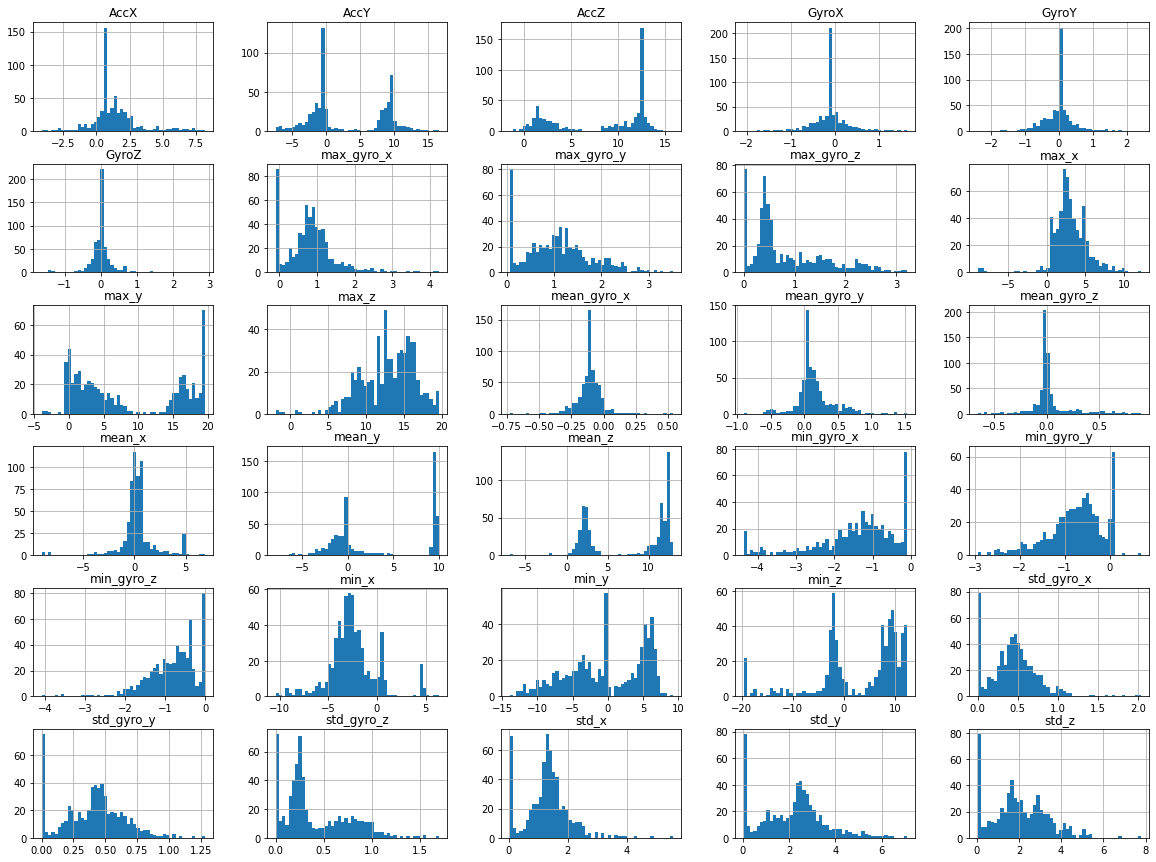

In [20]:
df = pd.read_csv('sensor_data_allg.csv')  # 
fig = df.hist(bins=50, figsize=(20,15))
plt.savefig("histo.png")

In [ ]:
#pruefen der korrelation

from pandas.plotting import scatter_matrix as scatmat
attributes = []

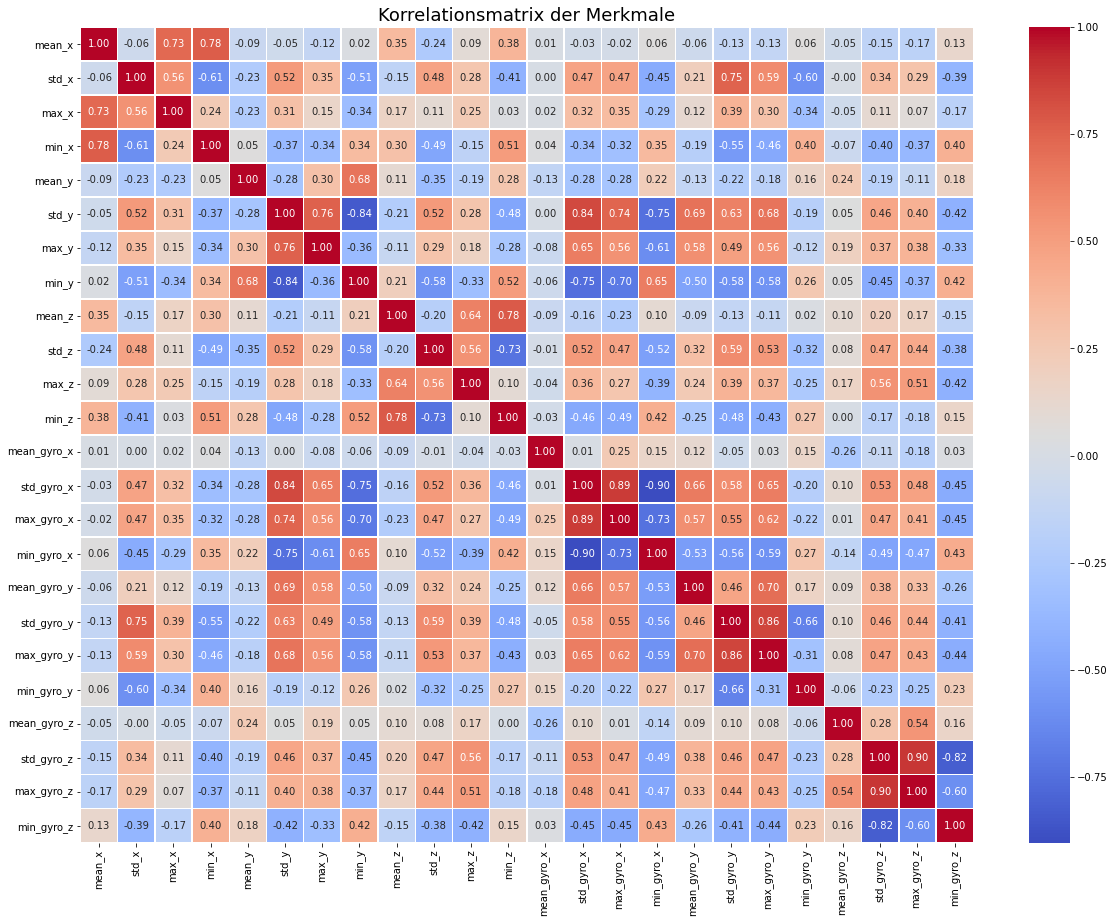

Merkmalspaare mit hoher Korrelation und signifikantem p-Wert:
std_y und min_y - Korrelation: -0.84, p-Wert: 4.970e-163
std_y und std_gyro_x - Korrelation: 0.84, p-Wert: 9.337e-160
min_y und std_y - Korrelation: -0.84, p-Wert: 4.970e-163
std_gyro_x und std_y - Korrelation: 0.84, p-Wert: 9.337e-160
std_gyro_x und max_gyro_x - Korrelation: 0.89, p-Wert: 9.975e-201
std_gyro_x und min_gyro_x - Korrelation: -0.90, p-Wert: 5.589e-222
max_gyro_x und std_gyro_x - Korrelation: 0.89, p-Wert: 9.975e-201
min_gyro_x und std_gyro_x - Korrelation: -0.90, p-Wert: 5.589e-222
std_gyro_y und max_gyro_y - Korrelation: 0.86, p-Wert: 2.403e-173
max_gyro_y und std_gyro_y - Korrelation: 0.86, p-Wert: 2.403e-173
std_gyro_z und max_gyro_z - Korrelation: 0.90, p-Wert: 8.159e-217
std_gyro_z und min_gyro_z - Korrelation: -0.82, p-Wert: 2.100e-148
max_gyro_z und std_gyro_z - Korrelation: 0.90, p-Wert: 8.159e-217
min_gyro_z und std_gyro_z - Korrelation: -0.82, p-Wert: 2.100e-148


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Laden der Merkmalsdaten
data = pd.read_csv('sensor_data_allg_plus_only.csv')  

# Überprüfen, ob alle Spalten numerisch sind
for column in data.columns:
    data[column] = pd.to_numeric(data[column], errors='coerce')

# Entfernen von Spalten mit fehlenden Werten (optional)
data = data.dropna(axis=1)

# Berechnung der Korrelation
correlation_matrix = data.corr()

# Visualisierung der Korrelation als Heatmap
plt.figure(figsize=(20, 15))  # Größere Abmessungen für eine bessere Lesbarkeit
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"size": 10})
plt.title('Korrelationsmatrix der Merkmale', fontsize=18)
plt.savefig("Korrelationsmatrix der Merkmale.png")
plt.show()

# Analyse der signifikanten Korrelationen (optional)
significance_matrix = pd.DataFrame(index=data.columns, columns=data.columns)

for col1 in data.columns:
    for col2 in data.columns:
        if col1 != col2:
            corr, p_value = pearsonr(data[col1], data[col2])
            significance_matrix.loc[col1, col2] = p_value

# Ausgabe der Paare mit hoher Korrelation und signifikantem p-Wert
threshold = 0.8
significant_pairs = []

for col1 in data.columns:
    for col2 in data.columns:
        if col1 != col2:
            corr_value = correlation_matrix.loc[col1, col2]
            p_value = significance_matrix.loc[col1, col2]
            if abs(corr_value) >= threshold and float(p_value) < 0.05:
                significant_pairs.append((col1, col2, corr_value, p_value))

print("Merkmalspaare mit hoher Korrelation und signifikantem p-Wert:")
for pair in significant_pairs:
    print(f"{pair[0]} und {pair[1]} - Korrelation: {pair[2]:.2f}, p-Wert: {pair[3]:.3e}")


<Figure size 432x288 with 0 Axes>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Beispielhafte Daten (ersetze dies durch deine eigenen Daten)
# Erstelle ein DataFrame mit Merkmalen und einer kategorischen Zielspalte
 

df = pd.read_csv('sensor_data_allg_plus_only.csv') 

# Kategorisches Merkmal 'Class' in numerische Werte umwandeln
label_encoder = LabelEncoder()
df['Class_Numeric'] = label_encoder.fit_transform(df['Class'])

# Scatterplot erstellen
plt.figure(figsize=(10, 6))

# Verwenden von Seaborn, um die Klassen im Scatterplot farblich zu unterscheiden
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Class', size='Feature2', sizes=(24, 200), alpha=0.6)

# Titel und Achsenbeschriftungen hinzufügen
plt.title('Scatterplot der Merkmale mit farbiger Klassenzuordnung')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(title='Klasse')

# Anzeige des Plots
plt.show()


KeyError: 'Class'

In [43]:
df = pd.read_csv('sensor_data_allg_plus_only.csv') 
df

,mean_x,std_x,max_x,min_x,mean_y,std_y,max_y,min_y,mean_z,std_z,...,max_gyro_x,min_gyro_x,mean_gyro_y,std_gyro_y,max_gyro_y,min_gyro_y,mean_gyro_z,std_gyro_z,max_gyro_z,min_gyro_z
0,0.666800,0.026607,0.74,0.61,-0.270200,0.030672,-0.18,-0.33,12.478000,0.045625,...,-0.10,-0.10,0.059400,0.002399,0.06,0.05,-0.010400,1.979487e-03,-0.01,-0.02
1,0.666600,0.039570,0.80,0.57,-0.268000,0.035456,-0.18,-0.35,12.489000,0.125344,...,-0.10,-0.11,0.059800,0.001414,0.06,0.05,-0.010200,1.414214e-03,-0.01,-0.02
2,0.661200,0.035722,0.76,0.59,-0.266800,0.027880,-0.19,-0.32,12.493800,0.049606,...,-0.10,-0.11,0.059600,0.001979,0.06,0.05,-0.010000,3.504671e-18,-0.01,-0.01
3,0.715400,1.809446,8.77,-7.41,-0.291000,0.718363,1.87,-3.10,12.474800,0.079776,...,-0.02,-0.19,0.058800,0.020468,0.13,-0.06,-0.016400,1.801106e-01,0.45,-0.73
4,0.741400,1.739562,9.75,-3.53,-0.327600,0.695691,2.06,-3.38,12.352400,1.044483,...,2.49,-1.62,0.055800,0.209422,0.74,-0.96,-0.036200,1.755561e-01,0.36,-0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.462800,0.897555,2.02,-1.69,-1.167600,0.853458,0.87,-2.53,12.586800,1.220203,...,0.12,-0.54,0.112000,0.188582,0.51,-0.64,0.858800,8.164474e-01,2.28,-0.84
596,-0.422000,0.869593,1.10,-3.07,-1.736200,1.344625,0.59,-4.44,12.480400,1.543800,...,0.51,-0.52,0.123400,0.282616,0.68,-0.64,-0.127800,6.573021e-01,0.84,-1.49
597,0.212200,0.882860,1.75,-1.79,-2.078000,1.323300,1.76,-4.44,12.288400,1.409787,...,0.33,-0.76,0.181000,0.271543,0.75,-0.39,-0.128000,8.469465e-01,1.88,-1.67
598,0.273800,0.881501,1.66,-1.47,-1.571000,0.907878,0.42,-3.32,12.520600,1.375959,...,0.14,-0.43,0.034600,0.162697,0.33,-0.43,0.895000,7.012038e-01,2.37,-0.34


In [ ]:

# 1. Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')  # 

# 2. Zielspalte und Merkmale extrahieren
X = df.drop(columns=['Zustand'])  # Merkmale (Features)
y = df['Zustand']  # Zielvariable (z. B. Ruhe, Betrieb, Transport)

# 3. Daten in Trainings- und Testdatensatz aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Daten skalieren
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. k-NN Klassifikator erstellen und trainieren
k = 15  # Anzahl der Nachbarn
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 6. Evaluierung auf dem Testdatensatz
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

# 7. Konfusionsmatrix erstellen und visualisieren
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Wahre Werte")
plt.show()

# 8. Modell und Scaler speichern
joblib.dump(knn, 'knn_model.pkl')  # Speichere das k-NN Modell
joblib.dump(scaler, 'scaler.pkl')  # Speichere den Scaler
print("Modell und Scaler wurden gespeichert.")

# 9. Neue Daten klassifizieren
def classify_new_data(new_data):
    """
    Klassifiziert neue Daten mit dem gespeicherten Modell und Scaler.
    :param new_data: numpy array oder DataFrame mit den neuen Datenpunkten
    :return: vorhergesagte Klasse(n)
    """
    # Modell und Scaler laden
    knn_loaded = joblib.load('knn_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    
    # Neue Daten skalieren
    new_data_scaled = scaler_loaded.transform(new_data)
    
    # Vorhersage
    prediction = knn_loaded.predict(new_data_scaled)
    return prediction

# Beispiel: Neue Daten klassifizieren
#new_data_example = final_df  # Beispielhafte Eingabedaten
new_prediction = classify_new_data(final_df)
print(f"Die vorhergesagte Klasse für die neuen Daten ist: {new_prediction[0]}")


Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment
Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment
Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment
Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment
Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment
Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment
Fehler beim Lesen der seriellen Daten: local variable 'data_queue' referenced before assignment


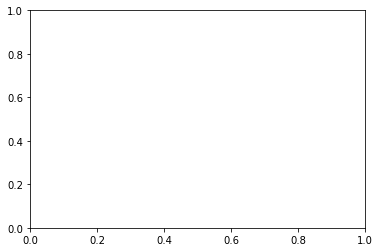

In [204]:
import tkinter as tk
from tkinter import ttk, messagebox
import serial
import numpy as np
import joblib
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import queue


# Annahme: Initialisierung der Variablen
ser = serial.Serial("COM7", 115200, timeout=1)  # Beispielhafte serielle Verbindung
data_queue = deque(maxlen=30)  # Datenwarteschlange mit maximal 30 Messwerten
running = False
current_state = None


# Lade das gespeicherte Modell und den Scaler
try:
    knn = joblib.load('knn_model.pkl')  # Das trainierte k-NN-Modell
    scaler = joblib.load('scaler.pkl')  # Der Scaler zur Normalisierung der Daten
except FileNotFoundError:
    messagebox.showerror("Fehler", "Modell und/oder Scaler nicht gefunden. Stelle sicher, dass sie vorhanden sind.")
    exit()

# Globale Variablen
ser = None
data_queue = queue.Queue(maxsize=1000)  # Warteschlange für Live-Daten
running = False
current_state = "-"  # Aktueller Zustand (z. B. Ruhe, Betrieb)

# Funktion zum Starten der seriellen Verbindung
def start_serial_connection():
    global ser
    port = port_entry.get()
    baud_rate = int(baud_rate_entry.get())
    try:
        ser = serial.Serial(port, baud_rate, timeout=1)
        messagebox.showinfo("Erfolg", f"Verbindung zu {port} hergestellt!")
    except Exception as e:
        messagebox.showerror("Fehler", f"Fehler beim Verbinden mit {port}: {e}")


def calculate_features(df, window_size=3):

    features = []

    # Berechne Merkmale für jedes Fenster
    for i in range(0, len(df), window_size):
        window = df.iloc[i:i + window_size]
        
        # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
        mean_x = window['AccX'].mean()
        std_x = window['AccX'].std()
        max_x = window['AccX'].max()
        min_x = window['AccX'].min()

        mean_y = window['AccY'].mean()
        std_y = window['AccY'].std()
        max_y = window['AccY'].max()
        min_y = window['AccY'].min()

        mean_z = window['AccZ'].mean()
        std_z = window['AccZ'].std()
        max_z = window['AccZ'].max()
        min_z = window['AccZ'].min()

        # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
        mean_gyro_x = window['GyroX'].mean()
        std_gyro_x = window['GyroX'].std()
        max_gyro_x = window['GyroX'].max()
        min_gyro_x = window['GyroX'].min()

        mean_gyro_y = window['GyroY'].mean()
        std_gyro_y = window['GyroY'].std()
        max_gyro_y = window['GyroY'].max()
        min_gyro_y = window['GyroY'].min()

        mean_gyro_z = window['GyroZ'].mean()
        std_gyro_z = window['GyroZ'].std()
        max_gyro_z = window['GyroZ'].max()
        min_gyro_z = window['GyroZ'].min()

        # Speichern der berechneten Merkmale für dieses Fenster
        features.append([mean_x, std_x, max_x, min_x, 
                         mean_y, std_y, max_y, min_y, 
                         mean_z, std_z, max_z, min_z,
                         mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                         mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                         mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

    # Erstelle ein DataFrame mit den berechneten Merkmalen
    features_df = pd.DataFrame(features, columns=[
        'mean_x', 'std_x', 'max_x', 'min_x',
        'mean_y', 'std_y', 'max_y', 'min_y',
        'mean_z', 'std_z', 'max_z', 'min_z',
        'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
        'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
        'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

    return features_df        
        
# Funktion zum Lesen der seriellen Daten
# Funktion zur kontinuierlichen Datensammlung und Zustandsbestimmung

# Funktion zur kontinuierlichen Datensammlung und Zustandsbestimmung
def read_serial_data():
    global running, current_state
    if not ser or not ser.is_open:
        messagebox.showerror("Fehler", "Serielle Verbindung ist nicht aktiv!")
        return
    
    running = True
    while running:
        try:
            # Lies eine Zeile aus dem seriellen Port
            line = ser.readline().decode('utf-8').strip()
            
            # Konvertiere die Zeile in eine Liste von floats (AccX, AccY, AccZ, GyroX, GyroY, GyroZ)
            values = np.array(line.split(","), dtype=np.float32)
            #values = [float(x) for x in line.split(",")]
            
            # Sicherstellen, dass 6 Werte (Beschleunigungs- und Gyroskopdaten) empfangen wurden
            if len(values) == 6:
                if len(data_queue) >= 30:
                    # Wenn die Warteschlange voll ist, entferne das älteste Element
                    data_queue.popleft()
                    #print(data_queue)
                    
                
                # Füge die neuen Messwerte in die Warteschlange ein
                data_queue.append(values)
                data_queue = np.array(data_queue, dtype=np.float32)
                
                # Berechne die Merkmale, wenn genügend Daten vorhanden sind
                if len(data_queue) == 30:
                    # Wandelt die Warteschlange in ein DataFrame um
                    window = pd.DataFrame(list(data_queue), columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"])
                    
                    # Berechne die Merkmale aus dem Fenster
                    features_df = calculate_features(window)
                    
                    # Skalieren der Merkmale 
                    scaled_features = scaler.transform(features_df)
                    
                    # Zustand vorhersagen
                    prediction = knn.predict(scaled_features)
                    current_state = prediction[0]
                    print(f"Vorhergesagter Zustand: {current_state}")
                    
        except Exception as e:
            print(f"Fehler beim Lesen der seriellen Daten: {e}")
            break
# Funktion zum Stoppen des Lesens
def stop_serial_reading():
    global running
    running = False

# Funktion zur Live-Visualisierung
def update_plot(i):
    global current_state
    if not data_queue.empty():
        data = list(data_queue.queue)  # Hole alle Werte aus der Queue
        ax.clear()
        ax.plot([d[0] for d in data], label="AccX")
        ax.plot([d[1] for d in data], label="AccY")
        ax.plot([d[2] for d in data], label="AccZ")
        ax.plot([d[3] for d in data], label="GyroX")
        ax.plot([d[4] for d in data], label="GyroY")
        ax.plot([d[5] for d in data], label="GyroZ")
        ax.legend(loc="upper left")
        ax.set_title("Live-Daten")
        ax.set_xlabel("Zeit")
        ax.set_ylabel("Sensorwerte")
        ax.grid()

    # Aktuellen Zustand anzeigen
    state_label.config(text=f"Aktueller Zustand: {current_state}")

# Funktion zum Beenden
def close_connection():
    global ser, running
    running = False
    if ser and ser.is_open:
        ser.close()
    root.destroy()

# GUI erstellen
root = tk.Tk()
root.title("Zustandserkennung mit Live-Visualisierung")

# Verbindungseinstellungen
frame_connection = ttk.LabelFrame(root, text="Serielle Verbindung")
frame_connection.grid(row=0, column=0, padx=10, pady=10, sticky="ew")

ttk.Label(frame_connection, text="Port:").grid(row=0, column=0, padx=5, pady=5)
port_entry = ttk.Entry(frame_connection)
port_entry.grid(row=0, column=1, padx=5, pady=5)
port_entry.insert(0, "COM7")

ttk.Label(frame_connection, text="Baudrate:").grid(row=1, column=0, padx=5, pady=5)
baud_rate_entry = ttk.Entry(frame_connection)
baud_rate_entry.grid(row=1, column=1, padx=5, pady=5)
baud_rate_entry.insert(0, "115200")

connect_button = ttk.Button(frame_connection, text="Verbinden", command=start_serial_connection)
connect_button.grid(row=2, column=0, columnspan=2, pady=5)

# Plot erstellen
fig, ax = plt.subplots(figsize=(6, 4))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().grid(row=1, column=0, padx=10, pady=10)

# Steuerungsbuttons
frame_controls = ttk.LabelFrame(root, text="Steuerung")
frame_controls.grid(row=2, column=0, padx=10, pady=10, sticky="ew")

start_button = ttk.Button(frame_controls, text="Start Visualisierung", command=lambda: root.after(100, read_serial_data))
start_button.grid(row=0, column=0, padx=5, pady=5)

stop_button = ttk.Button(frame_controls, text="Stop Visualisierung", command=stop_serial_reading)
stop_button.grid(row=0, column=1, padx=5, pady=5)

exit_button = ttk.Button(frame_controls, text="Beenden", command=close_connection)
exit_button.grid(row=0, column=2, padx=5, pady=5)

# Zustandserkennung
state_label = ttk.Label(root, text="Aktueller Zustand: -", font=("Arial", 14))
state_label.grid(row=3, column=0, padx=10, pady=10)

# Matplotlib Animation
ani = FuncAnimation(fig, update_plot, interval=100)

# Hauptschleife der GUI
root.mainloop()


In [ ]:
import serial
import pandas as pd
import numpy as np
import time

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM7 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Initialisierung
data = []
start_time = time.time()
duration = 30  # Dauer der Datensammlung in Sekunden
window_size = 3  # Fenstergröße für die Merkmalsberechnung
features = []

print("Datensammlung startet...")

# 3. Datensammlung
while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 4. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 5. Daten in einen DataFrame umwandeln
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
df = pd.DataFrame(data, columns=columns)

# 6. Merkmalsextraktion in Fenstern
for i in range(0, len(df), window_size):
    window = df.iloc[i:i + window_size]
    
    # Berechne Merkmale für die Beschleunigungsdaten (X, Y, Z)
    mean_x = window['AccX'].mean()
    std_x = window['AccX'].std()
    max_x = window['AccX'].max()
    min_x = window['AccX'].min()

    mean_y = window['AccY'].mean()
    std_y = window['AccY'].std()
    max_y = window['AccY'].max()
    min_y = window['AccY'].min()

    mean_z = window['AccZ'].mean()
    std_z = window['AccZ'].std()
    max_z = window['AccZ'].max()
    min_z = window['AccZ'].min()

    # Berechne Merkmale für die Gyroskopdaten (X, Y, Z)
    mean_gyro_x = window['GyroX'].mean()
    std_gyro_x = window['GyroX'].std()
    max_gyro_x = window['GyroX'].max()
    min_gyro_x = window['GyroX'].min()

    mean_gyro_y = window['GyroY'].mean()
    std_gyro_y = window['GyroY'].std()
    max_gyro_y = window['GyroY'].max()
    min_gyro_y = window['GyroY'].min()

    mean_gyro_z = window['GyroZ'].mean()
    std_gyro_z = window['GyroZ'].std()
    max_gyro_z = window['GyroZ'].max()
    min_gyro_z = window['GyroZ'].min()

    # Speichern der berechneten Merkmale für dieses Fenster
    features.append([mean_x, std_x, max_x, min_x, 
                     mean_y, std_y, max_y, min_y, 
                     mean_z, std_z, max_z, min_z,
                     mean_gyro_x, std_gyro_x, max_gyro_x, min_gyro_x,
                     mean_gyro_y, std_gyro_y, max_gyro_y, min_gyro_y,
                     mean_gyro_z, std_gyro_z, max_gyro_z, min_gyro_z])

# 7. Erstelle ein DataFrame mit den Merkmalen
features_df = pd.DataFrame(features, columns=[
    'mean_x', 'std_x', 'max_x', 'min_x',
    'mean_y', 'std_y', 'max_y', 'min_y',
    'mean_z', 'std_z', 'max_z', 'min_z',
    'mean_gyro_x', 'std_gyro_x', 'max_gyro_x', 'min_gyro_x',
    'mean_gyro_y', 'std_gyro_y', 'max_gyro_y', 'min_gyro_y',
    'mean_gyro_z', 'std_gyro_z', 'max_gyro_z', 'min_gyro_z'])

# 8. Speichern der Rohdaten und der Merkmale
df.to_csv('new_data_example_raw.csv', index=False)
features_df.to_csv('new_data_example_features.csv', index=False)

print("Rohdaten gespeichert in 'new_data_example_raw.csv'.")
print("Merkmale gespeichert in 'new_data_example_features.csv'.")

# Optional: Zeige die ersten paar Zeilen der Rohdaten und der Merkmale
print("\nErste Zeilen der Rohdaten:")
print(df.head())
print("\nErste Zeilen der Merkmale:")
print(features_df.head())


In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
import serial
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import joblib
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import queue

# Modell und Scaler laden
try:
    knn_model = joblib.load('knn_model.pkl')  # k-NN-Modell
    scaler = joblib.load('scaler.pkl')       # Scaler zur Normalisierung
except FileNotFoundError:
    print("Fehler: Modell und Scaler nicht gefunden.")
    exit()

# Globale Variablen
ser = None
data_buffer = []       # Temporärer Puffer für Sensorwerte
window_size = 30       # Anzahl der Werte pro Fenster
queue_data = queue.Queue(maxsize=100)
current_state = "-"    # Aktueller Zustand
running = False

# Funktion zur seriellen Verbindung
def start_serial():
    global ser
    port = port_entry.get()
    baud_rate = int(baud_rate_entry.get())
    try:
        ser = serial.Serial(port, baud_rate, timeout=1)
        messagebox.showinfo("Erfolg", f"Verbindung zu {port} hergestellt!")
    except Exception as e:
        messagebox.showerror("Fehler", f"Verbindung fehlgeschlagen: {e}")

# Funktion zum Stoppen der seriellen Verbindung
def stop_serial():
    global running
    running = False
    if ser and ser.is_open:
        ser.close()
    messagebox.showinfo("Info", "Serielle Verbindung geschlossen.")

# Funktion zur kontinuierlichen Datenaufnahme
def read_serial_data():
    global running, current_state, data_buffer
    if not ser or not ser.is_open:
        messagebox.showerror("Fehler", "Serielle Verbindung ist nicht aktiv.")
        return

    running = True

    while running:
        try:
            # Daten lesen
            line = ser.readline().decode('utf-8').strip()
            values = [float(x) for x in line.split(",")]
            
            # Überprüfen, ob die richtige Anzahl an Werten gelesen wurde
            if len(values) == 6:
                data_buffer.append(values)
            
            # Wenn genügend Werte für ein Fenster gesammelt wurden
            if len(data_buffer) >= window_size:
                window = data_buffer[:window_size]  # Nimm das aktuelle Fenster
                data_buffer = data_buffer[window_size:]  # Entferne verarbeitete Werte
                
                # Merkmale berechnen
                features = extract_features(window)
                
                # Zustände vorhersagen
                scaled_features = scaler.transform([features])
                prediction = knn_model.predict(scaled_features)
                current_state = prediction[0]
                
                # Daten in Queue für die Visualisierung speichern
                if queue_data.full():
                    queue_data.get()
                queue_data.put((window, current_state))
        except Exception as e:
            print(f"Fehler beim Lesen der Daten: {e}")
            break

# Funktion zur Extraktion von Merkmalen
def extract_features(data_window):
    df = pd.DataFrame(data_window, columns=["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"])
    features = []
    
    for col in df.columns:
        features.extend([
            df[col].mean(),
            df[col].std(),
            df[col].max(),
            df[col].min()
        ])
    return features

# Funktion zur Live-Visualisierung
def update_plot(i):
    global current_state
    if not queue_data.empty():
        window, state = queue_data.queue[-1]  # Hole die letzten Daten
        ax.clear()
        
        # Plotte Beschleunigungs- und Gyroskopdaten
        for i, label in enumerate(["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]):
            ax.plot([row[i] for row in window], label=label)
        
        ax.legend(loc="upper left")
        ax.set_title(f"Echtzeit-Daten (Zustand: {state})")
        ax.set_xlabel("Zeit")
        ax.set_ylabel("Sensorwerte")
        ax.grid()

    # Zustand anzeigen
    state_label.config(text=f"Aktueller Zustand: {current_state}")

# GUI erstellen
root = tk.Tk()
root.title("Echtzeit-Zustandserkennung")

# Serielle Verbindung
frame_connection = ttk.LabelFrame(root, text="Serielle Verbindung")
frame_connection.grid(row=0, column=0, padx=10, pady=10, sticky="ew")

ttk.Label(frame_connection, text="Port:").grid(row=0, column=0, padx=5, pady=5)
port_entry = ttk.Entry(frame_connection)
port_entry.grid(row=0, column=1, padx=5, pady=5)
port_entry.insert(0, "COM7")

ttk.Label(frame_connection, text="Baudrate:").grid(row=1, column=0, padx=5, pady=5)
baud_rate_entry = ttk.Entry(frame_connection)
baud_rate_entry.grid(row=1, column=1, padx=5, pady=5)
baud_rate_entry.insert(0, "115200")

connect_button = ttk.Button(frame_connection, text="Start", command=start_serial)
connect_button.grid(row=2, column=0, padx=5, pady=5)

stop_button = ttk.Button(frame_connection, text="Stop", command=stop_serial)
stop_button.grid(row=2, column=1, padx=5, pady=5)

# Plot erstellen
fig, ax = plt.subplots(figsize=(6, 4))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().grid(row=1, column=0, padx=10, pady=10)

# Zustand
state_label = ttk.Label(root, text="Aktueller Zustand: -", font=("Arial", 14))
state_label.grid(row=2, column=0, padx=10, pady=10)

# Animation
ani = FuncAnimation(fig, update_plot, interval=100)

# Hauptschleife starten
root.mainloop()


In [66]:
"""

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')

# 2. Zielspalte und Merkmale extrahieren
X = df.drop(columns=['Zustand'])  # Features
y = df['Zustand']  # Zielvariable

# 3. Daten in Trainings- und Testdatensatz aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Daten skalieren
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. k-NN Klassifikator erstellen und trainieren
k = 15  # Anzahl der Nachbarn
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# 6. Vorhersage auf dem Testdatensatz
y_pred = knn.predict(X_test)

# 7. Genauigkeit berechnen
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

# 8. Konfusionsmatrix erstellen
cm = confusion_matrix(y_test, y_pred)

# 9. Visualisierung der Konfusionsmatrix
classes = sorted(y.unique())  # Labels sortieren für korrekte Achsenbeschriftung
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Wahre Werte")
plt.show()


"""

'\n\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.metrics import accuracy_score, confusion_matrix\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# 1. Daten einlesen\ndf = pd.read_csv(\'sensor_data_allg.csv\')\n\n# 2. Zielspalte und Merkmale extrahieren\nX = df.drop(columns=[\'Zustand\'])  # Features\ny = df[\'Zustand\']  # Zielvariable\n\n# 3. Daten in Trainings- und Testdatensatz aufteilen\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)\n\n# 4. Daten skalieren\nscaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)\n\n# 5. k-NN Klassifikator erstellen und trainieren\nk = 15  # Anzahl der Nachbarn\nknn = KNeighborsClassifier(n_neighbors=k)\nknn.fit(X_train, y_train)\n\n# 6. Vorhersage auf dem Testdatensatz\ny_pred = knn.predict(X_t

In [63]:
"""
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')  # Lade die CSV-Datei, die Rohdaten + Merkmale enthält

# 2. Die Zielspalte ('Zustand') und Merkmale extrahieren
X = df.drop(columns=['Zustand'])  # Alle Spalten außer 'Label' als Features
y = df['Zustand']  # 'Label' ist die Zielvariable (Zustand: Ruhe, Betrieb, Transport)

# 3. k-NN Klassifikator erstellen und trainieren
k = 15  # Setze den Wert von k (k-Nachbarn)
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X, y)  # Trainiere den Klassifikator

# 4. Vorhersage (Verwendung des gesamten Datensatzes für die Evaluation)
y_pred = knn.predict(X)

# 5. Berechne die Accuracy (Genauigkeit des Modells)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")

# 6. Erstelle die Konfusionsmatrix
cm = confusion_matrix(y, y_pred)

# 7. Visualisierung der Konfusionsmatrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df['Zustand'].unique(), yticklabels=df['Zustand'].unique())
plt.title("Konfusionsmatrix")
plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Wahre Werte")
plt.show()
"""

'\nimport pandas as pd\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.metrics import accuracy_score, confusion_matrix\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# 1. Daten einlesen\ndf = pd.read_csv(\'sensor_data_allg.csv\')  # Lade die CSV-Datei, die Rohdaten + Merkmale enthält\n\n# 2. Die Zielspalte (\'Zustand\') und Merkmale extrahieren\nX = df.drop(columns=[\'Zustand\'])  # Alle Spalten außer \'Label\' als Features\ny = df[\'Zustand\']  # \'Label\' ist die Zielvariable (Zustand: Ruhe, Betrieb, Transport)\n\n# 3. k-NN Klassifikator erstellen und trainieren\nk = 15  # Setze den Wert von k (k-Nachbarn)\nknn = KNeighborsClassifier(n_neighbors=k)\nknn.fit(X, y)  # Trainiere den Klassifikator\n\n# 4. Vorhersage (Verwendung des gesamten Datensatzes für die Evaluation)\ny_pred = knn.predict(X)\n\n# 5. Berechne die Accuracy (Genauigkeit des Modells)\naccuracy = accuracy_score(y, y_pred)\nprint(f"Accuracy des k-NN Klassifikators: {accuracy * 100:.2f}%")\n\n

In [64]:
"""

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Schritt 1: Daten laden
df = pd.read_csv('sensor_data_allg.csv')

# Schritt 2: Merkmale und Labels definieren
X = df.drop(columns=['Zustand'])  # Alle Spalten außer Label
y = df['Zustand']  # Label-Spalte

# Schritt 3: Labels codieren
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Schritt 4: Daten in Trainings- und Testdaten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Schritt 5: k-NN-Modell erstellen und trainieren
k = 5  # Anzahl der Nachbarn
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Schritt 6: Vorhersage auf Testdaten
y_pred = knn.predict(X_test)

# Schritt 7: Modellbewertung
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Schritt 8: Konfusionsmatrix anzeigen
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Konfusionsmatrix')
plt.xlabel('Vorhergesagte Labels')
plt.ylabel('Wahre Labels')
plt.show()

# Schritt 9: Live-Zustandsanzeige
while True:
    # Simulierte Eingabe - hier können live Sensordaten eingebunden werden
    print("\nGeben Sie einen neuen Messwert ein oder brechen Sie mit 'q' ab:")
    input_values = input("Format: Wert1,Wert2,...,WertN: ")
    
    if input_values.lower() == 'q':
        print("Live-Zustandsanzeige beendet.")
        break
    
    try:
        # Sensordaten verarbeiten
        new_data = [float(x) for x in input_values.split(",")]
        if len(new_data) != X.shape[1]:
            print(f"Bitte geben Sie {X.shape[1]} Werte ein!")
            continue
        
        # Vorhersage
        state_pred = knn.predict([new_data])
        state_label = label_encoder.inverse_transform(state_pred)
        print(f"Vorhergesagter Zustand: {state_label[0]}")
    
    except Exception as e:
        print(f"Fehler: {e}")


"""

'\n\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import LabelEncoder\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.metrics import accuracy_score, confusion_matrix, classification_report\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Schritt 1: Daten laden\ndf = pd.read_csv(\'sensor_data_allg.csv\')\n\n# Schritt 2: Merkmale und Labels definieren\nX = df.drop(columns=[\'Zustand\'])  # Alle Spalten außer Label\ny = df[\'Zustand\']  # Label-Spalte\n\n# Schritt 3: Labels codieren\nlabel_encoder = LabelEncoder()\ny_encoded = label_encoder.fit_transform(y)\n\n# Schritt 4: Daten in Trainings- und Testdaten aufteilen\nX_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)\n\n# Schritt 5: k-NN-Modell erstellen und trainieren\nk = 5  # Anzahl der Nachbarn\nknn = KNeighborsClassifier(n_neighbors=k)\nknn.fit(X_train, y_train)\n\n# Schritt 6: Vorhersage auf Testdaten

In [65]:
"""

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Schritt 1: Daten einlesen
df = pd.read_csv('sensor_data_allg.csv')

# Schritt 2: Merkmale (X) und Label (y) definieren
X = df.drop(columns=['Zustand'])  # Alle Spalten außer 'Label' sind Merkmale
y = df['Zustand']  # 'Label' ist die Zielvariable

# Schritt 3: Daten in Trainings- und Testset aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Schritt 4: Merkmale skalieren
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Schritt 5: k-NN-Klassifikator trainieren
k = 5  # Die Anzahl der Nachbarn, kann angepasst werden
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Schritt 6: Vorhersagen auf dem Testset durchführen
y_pred = knn.predict(X_test)

# Schritt 7: Genauigkeit und Konfusionsmatrix berechnen
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Genauigkeit des k-NN-Klassifikators: {accuracy:.2f}")

# Schritt 8: Konfusionsmatrix visualisieren
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel("Vorhergesagte Labels")
plt.ylabel("Wahre Labels")
plt.title("Konfusionsmatrix des k-NN-Klassifikators")
plt.show()


"""

'\n\nimport pandas as pd\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.metrics import accuracy_score, confusion_matrix\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\n# Schritt 1: Daten einlesen\ndf = pd.read_csv(\'sensor_data_allg.csv\')\n\n# Schritt 2: Merkmale (X) und Label (y) definieren\nX = df.drop(columns=[\'Zustand\'])  # Alle Spalten außer \'Label\' sind Merkmale\ny = df[\'Zustand\']  # \'Label\' ist die Zielvariable\n\n# Schritt 3: Daten in Trainings- und Testset aufteilen\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)\n\n# Schritt 4: Merkmale skalieren\nscaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)\n\n# Schritt 5: k-NN-Klassifikator trainieren\nk = 5  # Die Anzahl der Nachbarn, kann angepasst werden\nknn = KNeighborsClassifier(n_neighbors=k)\nk

In [18]:
import pandas as pd
import numpy as np

# 1. Rohdaten laden
file_path = "sensor_data_ruhe.csv"  # Pfad zu den Rohdaten
df = pd.read_csv(file_path)

# 2. Merkmale berechnen
def calculate_features(data, window_size=50):
    """
    Berechnet aggregierte und dynamische Merkmale für den Zustand Ruhe.
    :param data: DataFrame mit Rohdaten
    :param window_size: Fenstergröße für Merkmalsberechnung
    :return: DataFrame mit berechneten Merkmalen und Label
    """
    features = []

    for i in range(0, len(data) - window_size, window_size):
        window = data.iloc[i:i + window_size]
        feature_set = {}

        # Aggregierte Merkmale
        for col in data.columns:
            feature_set[f"{col}_mean"] = window[col].mean()
            feature_set[f"{col}_std"] = window[col].std()
            feature_set[f"{col}_min"] = window[col].min()
            feature_set[f"{col}_max"] = window[col].max()

        # Dynamische Merkmale
        for col in data.columns:
            feature_set[f"{col}_range"] = window[col].max() - window[col].min()
            feature_set[f"{col}_peak_count"] = ((window[col].diff().fillna(0) > 0).sum())

        # Zustand ist bekannt: Ruhe
        feature_set["Label"] = "Ruhe"

        features.append(feature_set)

    return pd.DataFrame(features)

# 3. Merkmale berechnen
features_df = calculate_features(df)

# 4. Ergebnisse speichern
output_path = "features_ruhe.csv"
features_df.to_csv(output_path, index=False)
print(f"Merkmale und Labels gespeichert in {output_path}")

# 5. Optionale Vorschau der berechneten Merkmale
features_df.head()


Merkmale und Labels gespeichert in features_ruhe.csv


,AccX_mean,AccX_std,AccX_min,AccX_max,AccY_mean,AccY_std,AccY_min,AccY_max,AccZ_mean,AccZ_std,...,AccY_peak_count,AccZ_range,AccZ_peak_count,GyroX_range,GyroX_peak_count,GyroY_range,GyroY_peak_count,GyroZ_range,GyroZ_peak_count,Label
0,0.7788,0.033784,0.69,0.85,-0.3976,0.029455,-0.48,-0.35,12.3748,0.046036,...,20,0.19,20,0.01,12,0.01,1,0.01,2,Ruhe
1,0.7766,0.036344,0.70,0.85,-0.3932,0.037766,-0.48,-0.31,12.3630,0.049867,...,22,0.24,24,0.01,14,0.01,6,0.01,1,Ruhe
2,0.7814,0.032764,0.72,0.88,-0.4056,0.028725,-0.46,-0.33,12.3734,0.053552,...,23,0.26,25,0.01,13,0.01,6,0.00,0,Ruhe
3,0.7782,0.034148,0.68,0.83,-0.4118,0.034858,-0.50,-0.35,12.3634,0.050854,...,23,0.24,26,0.01,14,0.01,4,0.01,3,Ruhe
4,0.7852,0.027645,0.72,0.87,-0.3986,0.028572,-0.45,-0.34,12.3606,0.047398,...,21,0.21,22,0.01,12,0.01,5,0.00,0,Ruhe


In [20]:
import serial
import pandas as pd
import time


# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM3 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Daten sammeln
data = []
start_time = time.time()
duration = 150  # Datenaufnahmezeit (in Sekunden)

print("Daten werden gesammelt...")

while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 3. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 4. Daten in einen DataFrame umwandeln
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
df = pd.DataFrame(data, columns=columns)

# 5. Daten speichern
df.to_csv("sensor_data_transport.csv", index=False)
print("Daten gespeichert in sensor_data_transport.csv")

# Optional: Daten anzeigen
print(df.head())

Daten werden gesammelt...
Datenaufnahme beendet.
Daten gespeichert in sensor_data_transport.csv


NameError: name 'df_transport' is not defined

In [23]:
import pandas as pd
import numpy as np

# 1. Rohdaten laden
file_path = "sensor_data_transport.csv"  # Pfad zu den Rohdaten
df = pd.read_csv(file_path)

# 2. Merkmale berechnen
def calculate_features(data, window_size=50):
    """
    Berechnet aggregierte und dynamische Merkmale für den Zustand Ruhe.
    :param data: DataFrame mit Rohdaten
    :param window_size: Fenstergröße für Merkmalsberechnung
    :return: DataFrame mit berechneten Merkmalen und Label
    """
    features = []

    for i in range(0, len(data) - window_size, window_size):
        window = data.iloc[i:i + window_size]
        feature_set = {}

        # Aggregierte Merkmale
        for col in data.columns:
            feature_set[f"{col}_mean"] = window[col].mean()
            feature_set[f"{col}_std"] = window[col].std()
            feature_set[f"{col}_min"] = window[col].min()
            feature_set[f"{col}_max"] = window[col].max()

        # Dynamische Merkmale
        for col in data.columns:
            feature_set[f"{col}_range"] = window[col].max() - window[col].min()
            feature_set[f"{col}_peak_count"] = ((window[col].diff().fillna(0) > 0).sum())

        # Zustand ist bekannt: Ruhe
        feature_set["Label"] = "Transport"

        features.append(feature_set)

    return pd.DataFrame(features)

# 3. Merkmale berechnen
features_df = calculate_features(df)

# 4. Ergebnisse speichern
output_path_transport = "features_transport.csv"
features_df.to_csv(output_path, index=False)
print(f"Merkmale und Labels gespeichert in {output_path_transport}")

# 5. Optionale Vorschau der berechneten Merkmale
features_df.head()


Merkmale und Labels gespeichert in features_transport.csv


,AccX_mean,AccX_std,AccX_min,AccX_max,AccY_mean,AccY_std,AccY_min,AccY_max,AccZ_mean,AccZ_std,...,AccY_peak_count,AccZ_range,AccZ_peak_count,GyroX_range,GyroX_peak_count,GyroY_range,GyroY_peak_count,GyroZ_range,GyroZ_peak_count,Label
0,-1.3434,0.508602,-2.62,-0.27,9.4862,0.997677,6.69,12.50,2.4338,0.355963,...,26,2.02,24,2.13,23,3.67,22,2.91,26,Transport
1,-1.4910,0.391701,-2.55,-0.76,9.8550,1.535508,7.08,13.70,2.7634,0.255028,...,25,1.10,23,1.22,22,2.46,26,3.49,25,Transport
2,-1.5222,0.603007,-2.81,-0.46,9.7370,1.893508,6.46,13.92,2.8488,0.243148,...,22,1.00,26,2.46,20,3.47,31,3.61,23,Transport
3,-1.4712,0.508726,-2.37,-0.53,9.6036,2.067204,5.30,13.32,2.7622,0.356189,...,26,1.65,23,3.30,22,3.47,22,3.04,27,Transport
4,-1.4228,0.448180,-2.35,-0.71,9.6936,1.972824,5.96,14.23,2.7956,0.247948,...,27,1.05,24,1.95,25,2.44,23,2.18,23,Transport


In [24]:
features_df

,AccX_mean,AccX_std,AccX_min,AccX_max,AccY_mean,AccY_std,AccY_min,AccY_max,AccZ_mean,AccZ_std,...,AccY_peak_count,AccZ_range,AccZ_peak_count,GyroX_range,GyroX_peak_count,GyroY_range,GyroY_peak_count,GyroZ_range,GyroZ_peak_count,Label
0,-1.3434,0.508602,-2.62,-0.27,9.4862,0.997677,6.69,12.50,2.4338,0.355963,...,26,2.02,24,2.13,23,3.67,22,2.91,26,Transport
1,-1.4910,0.391701,-2.55,-0.76,9.8550,1.535508,7.08,13.70,2.7634,0.255028,...,25,1.10,23,1.22,22,2.46,26,3.49,25,Transport
2,-1.5222,0.603007,-2.81,-0.46,9.7370,1.893508,6.46,13.92,2.8488,0.243148,...,22,1.00,26,2.46,20,3.47,31,3.61,23,Transport
3,-1.4712,0.508726,-2.37,-0.53,9.6036,2.067204,5.30,13.32,2.7622,0.356189,...,26,1.65,23,3.30,22,3.47,22,3.04,27,Transport
4,-1.4228,0.448180,-2.35,-0.71,9.6936,1.972824,5.96,14.23,2.7956,0.247948,...,27,1.05,24,1.95,25,2.44,23,2.18,23,Transport
5,-1.5720,0.399826,-2.49,-0.86,9.5696,1.135147,6.68,11.58,2.7310,0.353081,...,26,1.38,23,2.61,23,3.91,23,3.50,25,Transport
6,-1.7360,0.543605,-2.62,-0.67,9.6568,1.379702,6.24,14.62,2.9912,0.343034,...,27,1.34,25,3.92,22,5.32,24,3.17,23,Transport
7,-1.8392,0.709193,-3.47,-0.37,9.6022,2.060656,5.61,14.30,2.8528,0.511317,...,27,3.34,23,2.98,19,5.14,27,4.54,24,Transport
8,-1.8958,0.511931,-3.00,-0.74,9.7018,1.140268,7.20,12.19,3.1412,0.402379,...,28,2.04,24,2.64,26,4.20,21,3.19,24,Transport
9,-1.9894,0.388101,-3.03,-1.11,9.6864,1.155943,6.97,11.80,3.1534,0.552163,...,29,2.45,22,3.64,27,4.58,26,4.86,20,Transport


KeyboardInterrupt: 

In [26]:
import serial
import pandas as pd
import time

# 1. Serielle Verbindung mit Arduino herstellen
port = "COM7"  # Ersetze COM3 durch den richtigen Port
baud_rate = 115200
ser = serial.Serial(port, baud_rate, timeout=1)

# 2. Daten sammeln
data = []
start_time = time.time()
duration = 150  # Datenaufnahmezeit (in Sekunden)

print("Daten werden gesammelt...")

while time.time() - start_time < duration:
    try:
        # Eine Zeile von Arduino lesen
        line = ser.readline().decode('utf-8').strip()
        
        # CSV-Werte in eine Liste umwandeln
        values = [float(x) for x in line.split(",")]
        if len(values) == 6:  # Sicherstellen, dass alle 6 Werte gelesen wurden
            data.append(values)
    except Exception as e:
        print(f"Fehler beim Lesen der Daten: {e}")

# 3. Serielle Verbindung schließen
ser.close()
print("Datenaufnahme beendet.")

# 4. Daten in einen DataFrame umwandeln
columns = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
df = pd.DataFrame(data, columns=columns)

# 5. Daten speichern
df.to_csv("sensor_data_ruhe.csv", index=False)
print("Daten gespeichert in sensor_data_ruhe.csv")

# Optional: Daten anzeigen
print(df.head())


['-0.17', '-0.44', '12.32', '-0.10', '0.06', '-0.02']